# Taller: Creación y Visualización de KPIs

## Objetivos de Aprendizaje

* **De Conocimientos:** Evidenciar cómo un Sistema de Información Gerencial (MIS) sintetiza los datos atómicos y transaccionales de un *Transaction Processing System* (TPS) en un repositorio común para generar reportes estructurados que apoyen la toma de decisiones medibles (KPIs).
* **De Destrezas:** Aplicar el enfoque de sistemas para resolver un problema de TI organizacional, mapeando el flujo desde los *Data Items* elementales hasta el *Knowledge* estratégico.
* **De Valores y Actitudes:** Experimentar el trabajo en equipo a través del codiseño de una solución de software empresarial y la presentación de argumentos técnicos efectivos.

## Introducción (Enlace Arquitectónico)

Recordemos que los **Sistemas de Procesamiento de Transacciones (TPS)** se encargan de monitorear, recolectar, almacenar y procesar los datos de las operaciones básicas diarias de la organización (datos en tiempo real, de alto volumen y nivel atómico).

Por otro lado, los **Sistemas de Información Gerencial (MIS)** acceden a estos repositorios comunes de datos transaccionales para resumirlos, procesarlos y presentar reportes estructurados (como indicadores clave de rendimiento o **KPIs**) orientados a mandos medios y gerenciales. Nuestro objetivo de hoy es construir la capa del MIS que consume los datos del TPS que ustedes ya desarrollaron.

## 1: Construir Conocimiento desde los Datos

En esta fase inicial, cada equipo de trabajo debe formalizar el ciclo de vida de la información que va a visualizar, e identificar **3 KPIs** de su proyecto, para construir en esta actividad. Para los **3 KPIs** seleccionados, completen la siguiente matriz conceptual en su informe:

1. **Data Items (Datos Crudos):** Describan los hechos elementales almacenados en su TPS sin organizar (ej. marcas de tiempo, IDs de transacciones, valores numéricos crudos).
2. **Information (Información Organizada):** Expliquen cómo la agregación o procesamiento matemático de esos datos les asigna un significado y un valor contextual para el negocio.
3. **Knowledge (Conocimiento Aplicado):** Describan la lógica o experiencia acumulada que determina qué decisión operativa o táctica se tomará según el comportamiento del KPI (ej. si el indicador supera un umbral de alerta, qué proceso se dispara).

> **Aviso de Calidad de Datos:** Al diseñar su flujo, recuerden el principio **GIGO (*Garbage In, Garbage Out*)**. Si los datos capturados originalmente por su TPS contienen inconsistencias o faltas de integridad, el reporte generado por el MIS carecerá de confiabilidad y validez para la toma de decisiones.

Objetivo: Aumentar la frecuencia mensual de clientes

| Nivel | Descripción |
|---|---|
| **Data Items** | Nombre del cliente, fecha de transacción, monto de consumo. |
| **Information (Información Organizada)** | Contar el número total de visitas realizadas en un mes. |
| **Knowledge (Conocimiento Aplicado)** | Si el cliente alcanza 18 visitas mensuales, el sistema dispara automáticamente la entrega de un bono de 10 dólares para la siguiente compra. |

---
## Objetivo: Aumentar el consumo promedio de cada cliente por día

| Nivel | Descripción |
|---|---|
| **Data Items** | Montos de facturas, cantidad de productos, fecha de transacción. |
| **Information (Información Organizada)** | División del ingreso total diario entre la cantidad total de facturas emitidas en ese mismo día. |
| **Knowledge (Conocimiento Aplicado)** | Si deseo que el valor promedio aumente implementaré una estrategia como ofrecer un producto de promoción por un precio reducido. |

---

## Objetivo: Priorizar categoría de productos

| Nivel | Descripción |
|---|---|
| **Data Items** | Categoría del producto, precio unitario, cantidad vendida. |
| **Information (Información Organizada)** | Cálculo de la participación de cada categoría (Ingreso de la categoría / Ingreso Total) * 100 |
| **Knowledge (Conocimiento Aplicado)** | Observando qué categorías tienen mayor porcentaje de participación, se debe priorizar su inventario, abastecimiento y promociones destacadas en el dashboard. |


## 2: Mapeo de Atributos y Boceto de Interfaz

Antes de proceder a la escritura de código, es fundamental realizar el diseño lógico y visual de la solución.

### 2.1 Mapeo en el Esquema de Base de Datos
Identifiquen en las tablas CSV de la base de datos de su TPS cuáles son las entidades, y atributos (*Data Entities & Attributes*) que se deben usar para extraer la información. Documenten las tablas involucradas y las relaciones entre ellas.

### 2.2 Bocetado Visual (Mockup)
Diseñen la interfaz del *Dashboard* o reporte estructural donde se mostrarán los 3 KPIs.
* Pueden utilizar **cualquier herramienta de dibujo o diseño** para generar este boceto (desde herramientas profesionales de prototipado, pasando por Canvas vectoriales, hasta el software básico **Paint**).
* El boceto debe justificar la elección de la visualización (ej. gráficos de líneas para tendencias temporales, gráficos de barras para comparativas de categorías, o tarjetas numéricas de alto impacto para valores acumulados).

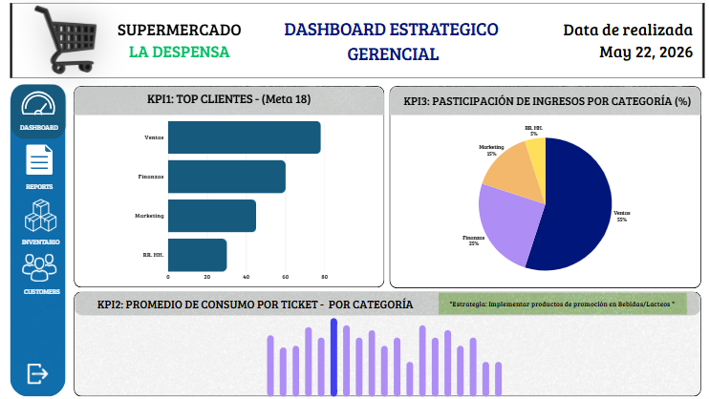

## 3: Construcción e Implementación de los KPIs

### Instrucciones Técnicas:
1. **Conexión al Repositorio:** El MIS que estamos construyendo no debe tener el mismo repositorio Git que el TPS. El MIS debe poder tener acceso a la base de datos o dataset de transacciones de su TPS.
2. **Procesamiento de Datos:** Utilicen las librerías de análisis de datos (como `pandas`) para cargar los datos crudos, realizar las uniones (*joins*), agrupaciones (*groupby*) y cálculos requeridos por las reglas de negocio de sus 3 KPIs.
3. **Generación de las Visualizaciones:** Programen la capa gráfica de su MIS (utilizando librerías como `matplotlib`, o `seaborn`). Asegúrense de que los gráficos sean limpios, estén correctamente etiquetados (ejes, títulos, leyendas) y correspondan fielmente a los mockups diseñados en el Paso 2.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de Datasets

Se cargan los archivos de facturas, productos y clientes para el análisis.

In [11]:
facturas = pd.read_csv(
    'facturas.txt',
    sep=';',
    names=['Hora', 'Nombre_Cliente', 'Afiliacion', 'Producto', 'Precio', 'Cantidad']
)

productos = pd.read_csv(
    'productos.txt',
    sep=';',
    names=['ID', 'Producto', 'Categoria', 'Precio_Unitario', 'Stock']
)

clientes = pd.read_csv(
    'clientes.txt',
    sep=';',
    names=['ID', 'Nombre', 'Cedula', 'Tipo']
)

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## Procesamiento de Datos

Se calcula el ingreso total por transacción y se integran las categorías de productos.

In [12]:
facturas['Ingreso'] = facturas['Precio'] * facturas['Cantidad']

df = pd.merge(
    facturas,
    productos[['Producto', 'Categoria']],
    on='Producto',
    how='left'
)

print("Datos procesados correctamente.")

Datos procesados correctamente.


## KPI 1: Número de visitas por cliente

Regla de negocio:
Si el cliente alcanza 18 visitas mensuales se otorga un bono.

In [13]:
kpi1 = facturas.groupby('Nombre_Cliente')['Hora'].count().reset_index()

kpi1.columns = ['Cliente', 'Visitas']

kpi1.head()

,Cliente,Visitas
0,Alejandro Morales,339
1,Alejandro Vásquez,360
2,Alicia Castro,361
3,Alicia Díaz,351
4,Alicia Intriago,367


## KPI 2: Consumo promedio por categoría

Permite analizar el comportamiento promedio de consumo.

In [14]:
kpi2 = df.groupby('Categoria')['Ingreso'].mean().reset_index()

kpi2.columns = ['Categoria', 'Promedio_Consumo']

kpi2.head()

,Categoria,Promedio_Consumo
0,Abarrotes,7.059610
1,Bebidas,11.541750
2,Carnes,19.828622
3,Cocina,16.077691
4,Congelados,20.937209


## KPI 3: Participación de ingresos por categoría

Se calcula qué porcentaje representa cada categoría respecto al ingreso total.

In [17]:
kpi3 = df.groupby('Categoria')['Ingreso'].sum().reset_index()

total = kpi3['Ingreso'].sum()

kpi3['Participacion'] = (kpi3['Ingreso'] / total) * 100

kpi3.head()

,Categoria,Ingreso,Participacion
0,Abarrotes,31662.35,7.393246
1,Bebidas,44839.70,10.470194
2,Carnes,62142.90,14.510539
3,Cocina,45114.00,10.534244
4,Congelados,22507.50,5.255564


print(df.head())

print(kpi3.head())

print(kpi3.dtypes)

Text(0.5, 1.0, 'KPI 3: Participación de Ingresos')

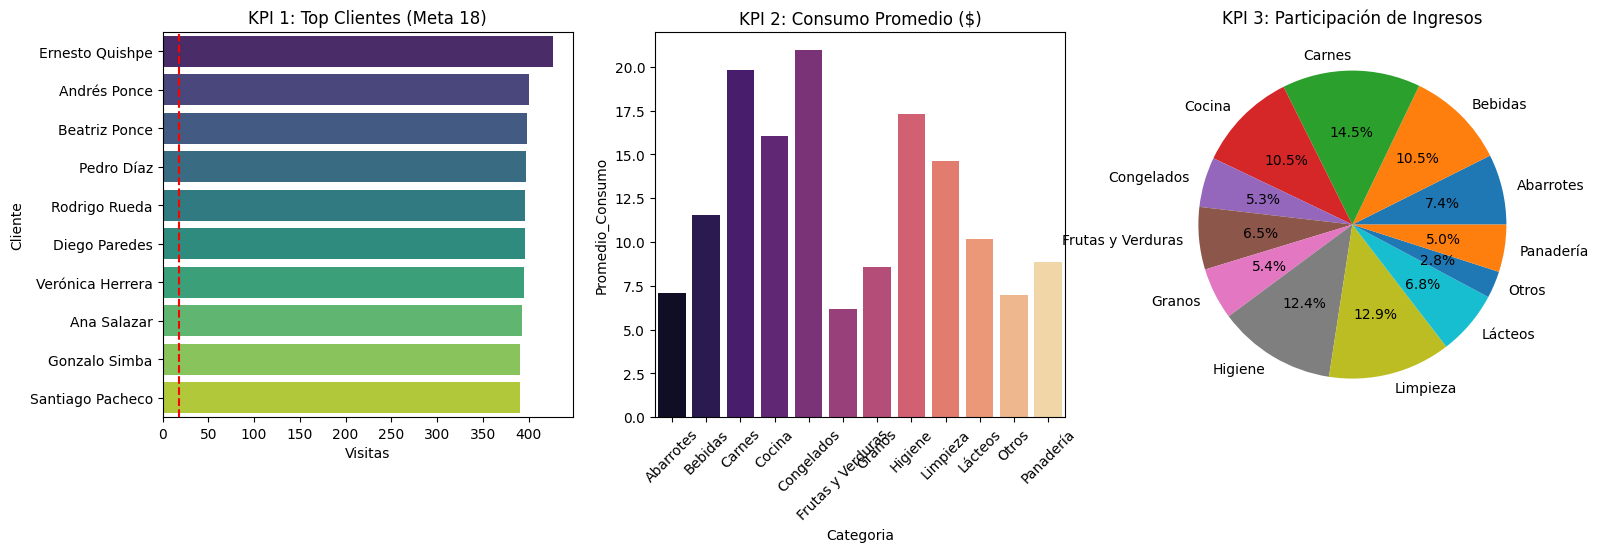

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1
top_10 = kpi1.sort_values(by='Visitas', ascending=False).head(10)

sns.barplot(
    data=top_10,
    x='Visitas',
    y='Cliente',
    ax=axes[0],
    palette='viridis',
    hue='Cliente',
    legend=False
)

axes[0].set_title('KPI 1: Top Clientes (Meta 18)')
axes[0].axvline(18, color='red', linestyle='--', label='Meta')

# Gráfico 2
sns.barplot(
    data=kpi2,
    x='Categoria',
    y='Promedio_Consumo',
    ax=axes[1],
    palette='magma',
    hue='Categoria',
    legend=False
)

axes[1].set_title('KPI 2: Consumo Promedio ($)')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3

kpi3_clean = kpi3.dropna()

axes[2].pie(
    kpi3_clean['Participacion'],
    labels=kpi3_clean['Categoria'],
    autopct='%1.1f%%'
)

axes[2].set_title('KPI 3: Participación de Ingresos')

## Visualización de KPIs

Se generan gráficos para apoyar la interpretación de resultados.

## 4: Validación de Atributos de Información e Interpretación Gerencial

Para consolidar el taller, el equipo evaluará de forma analítica los resultados obtenidos antes de la entrega final.

### 4.1 Matriz de Atributos de Valor
Verifiquen de manera crítica si la información que genera su celda de código cumple con las siguientes características esenciales:
* **Simplicidad:** ¿El gráfico evita la sobrecarga de información y destaca lo realmente importante?
* **Oportunidad (*Timeliness*):** ¿La consulta procesa los datos con la velocidad requerida para que el administrador actúe a tiempo?
* **Accesibilidad:** ¿El formato del reporte permite que un usuario no técnico interprete el resultado de un solo vistazo?

### 4.2 Documentación de Interpretación Gerencial
Para cada uno de los 3 KPIs implementados, redacten un párrafo analítico en formato de Markdown que responda a la siguiente estructura:
> *"Si este indicador clave de rendimiento muestra un comportamiento [positivo/negativo/fuera de umbral], la acción correctiva o estratégica que la gerencia debe ejecutar de inmediato es..."*

## Evaluación de KPIs

| KPI | Simplicidad | Oportunidad (Timeliness) | Accesibilidad |
|---|---|---|---|
| **1. Frecuencia Mensual** | Alta:<br>El boxplot permite visualizar rápidamente la distribución de visitas. | Alta:<br>La consulta con `groupby` procesa los datos rápidamente. | Alta:<br>La mediana facilita interpretar si las visitas son altas o bajas. |
| **2. Consumo Diario** | Alta:<br>El gráfico de líneas muestra claramente la tendencia del consumo diario. | Alta:<br>Las transacciones se procesan rápidamente para apoyar decisiones oportunas. | Alta:<br>La línea permite identificar aumentos o disminuciones fácilmente. |
| **3. Priorización Categoría** | Alta:<br>El gráfico de barras permite identificar las categorías más importantes. | Alta:<br>El cruce entre facturas y productos es eficiente y rápido. | Alta:<br>Los porcentajes facilitan interpretar los resultados visualmente. |

## Interpretación de KPIs y Acciones Estratégicas

### KPI 1: Frecuencia mensual de clientes

Si este KPI presenta resultados menores al límite establecido de **18 visitas mensuales**, la gerencia debería aplicar estrategias para recuperar la frecuencia de los clientes.

Una posible acción sería enviar promociones mediante correo electrónico o notificaciones push, ofreciendo un bono promocional de **10 dólares** para motivar a los clientes a regresar y aumentar sus visitas a los puntos de venta.

---

### KPI 2: Consumo promedio diario

Si este KPI muestra una disminución en el consumo promedio diario, la empresa puede implementar promociones cruzadas o paquetes de productos a menor precio.

Esto ayudaría a incentivar compras adicionales y aumentar el valor promedio de cada factura realizada por los clientes.

---

### KPI 3: Priorización categoría de productos

Si este KPI evidencia que ciertas categorías importantes están perdiendo participación en ventas, la gerencia debería reorganizar el inventario y dar mayor visibilidad a los productos con mayor rentabilidad.

También se podrían reforzar promociones y asegurar una reposición más rápida del stock para mejorar el rendimiento de las categorías más relevantes.